In [92]:
import numpy as np
import matplotlib.pyplot as plt
from pulp import *
from scipy.spatial.distance import cdist
from matplotlib.patches import Rectangle

In [93]:
print(listSolvers(onlyAvailable=True))
solver = GUROBI(msg=True)
print("Gurobi disponible:", solver.available())

['GUROBI', 'PULP_CBC_CMD']
Restricted license - for non-production use only - expires 2027-11-29
Gurobi disponible: True


In [94]:
#Parámetros del problema
m=10 #Número de usuarios
n=5 #Número máximo de médicos
dt=10 #Tiempo en minutos
K=144 #Número de intervalos de Tiempo
velocidad=30 #En unidades de km/hora
r=np.random.uniform(low=0, high=30, size=(m,2)) #Posiciones de los usuarios
beta=int(16*60/dt) #Numero máximo de turnos seguidos por un médico, 
distancias = cdist(r, r)
delta=distancias/velocidad*60 #Matriz de distancias en minutos
delta=np.ceil(delta/dt) #Matriz de distancias en intervalos de tiempo
delta={(i+1,j+1):delta[i,j] for i in range(0,m) for j in range(0,m)}
#Generación de parámetros de servicio de los pacientes
a={i:np.random.randint(low=1, high=K-10) for i in range(1,m+1)} #Tiempo de llegada de los usuarios
b={}
c={}
for i in range(1,m+1):
    ventana=np.random.randint(low=4, high=20) #Duración de la ventana de servicio
    ventana=min(144-a[i]-1, ventana)
    b[i]=a[i]+ventana+1
    duracion=np.random.randint(low=1, high=b[i]-a[i])
    c[i]=duracion

#Parámetros auxiliares para construir las ecuaciones
alfa={}
tau={i:[] for i in range(1,m+1)}
for i in range(1,m+1):
    for k in range(1, K+1):
        if(k>=a[i] and k<=b[i]-c[i]+1):
            alfa[i,k]=1
            tau[i].append(k)
        else:
            alfa[i,k]=0


In [95]:
range(1,K+1-beta)

range(1, 49)

In [96]:
prob=LpProblem('Optimizacion_turnos_horarios_atencion', LpMinimize) #Dado que importamos toda la librería de Pulp
#Construccion de variables
#Uso de médicos:
y={(j,k):LpVariable('Doctor_'+str(j)+'_'+str(k), cat=LpBinary) for j in range(1,n+1) for k in range(1,K+1-beta)}
#Inicio de atención de pacientes
x={}
for i in range(1,m+1):
    for j in range(1, n+1):
        for k in range(1,K+1):
            if(alfa[i,k]==1): 
                x[i,j,k]=LpVariable(f'Us{i}_Dr{j}_Time{k}', cat=LpBinary)
#orden de los pacientes con un mismo médico
z={}
for a in range(1,m+1):
    z['S',a]=LpVariable(f'Z_Src_{a}', cat=LpBinary)
    z[a,'T']=LpVariable(f'Z_{a}_Tgt', cat=LpBinary)
            
    for b in range(1,m+1):
        if(a!=b):
            z[a,b]=LpVariable(f'Z_{a}_{b}', cat=LpBinary)

#Función objetivo
prob+=lpSum([y[j] for j in y.keys()])*0+lpSum([z[j] for j in z.keys()]), 'Función objetivo'

#1. Restricción de que alguien tiene que atender al usuario, pero solo un doctor, si este está activo
for i in range(1,m+1):
    for j in range(1,n+1):
        for k in tau[i]:
            suma=0
            for s in range(max(1,k-beta+c[i]), k+1):
                if((j,s) in y.keys()):
                    suma+=y[j,s]
                    
            prob+=x[i,j,k]<=suma
            #print(i,j,k, range(max(1,k-beta+c[i]), k+1))
            #print(x[i,j,k]<=suma)
#2. A un usuario lo tiene que atender alguien
for i in range(1,m+1):
    suma=0
    for j in range(1,n+1):
        for k in tau[i]:
            suma+=x[i,j,k]
    prob+=suma==1

#3. Tantos flujos en enrutamiento como médicos hay
prob+=lpSum([z['S',a] for a in range(1,m+1)])==lpSum([y[j] for j in y.keys()])
print(lpSum([z['S',a] for a in range(1,m+1)])==lpSum([y[j] for j in y.keys()]))

#4. Restricción de flujo en cada nodo intermedio, para garantizar el enrutamiento
for i in range(1,m+1):
    suma=z['S',i]-z[i,'T']
    for a in range(1,m+1):
        if(a!=i):
            suma+=z[a,i]
            suma-=z[i,a]
    prob+=suma==0
    print(suma==0)

#5. Flujos hacia el target
suma=0
for j in range(1,n+1):
    for k in tau[i]:
        if((j,k) in y.keys()):
            suma+=y[j,k]
prob+=lpSum([z[a,'T'] for a in range(1,m+1)])==lpSum([y[j] for j in y.keys()])
print(lpSum([z[a,'T'] for a in range(1,m+1)])==lpSum([y[j] for j in y.keys()]))
M=1000
#6. Restricción de tiempos si dos pacientes son consecutivos para un mismo médico
for a in range(1,m+1):
    for b in range(1,m+1):
        if(a!=b):
            for j in range(1,n+1):
                for k in tau[b]:
                    suma=0
                    for s in range(max(1,k-c[a]-delta[a,b]+1, k+1)):
                        if((a,j,s) in x.keys()):
                            suma+=x[a,j,s]
                    #prob+=x[b,j,k]<=1-suma+M*(1-z[a,b])
                        #print(x[b,j,k]<=1-suma+M*(1-z[a,b]))
#7. A un usuario tiene que llegar una ruta de atención
for i in range(1,m+1):
    prob+=lpSum([z[a,i] for a in range(1,m+1) if a!=i])+z['S',i]==1
    pass
 


-Doctor_1_1 - Doctor_1_10 - Doctor_1_11 - Doctor_1_12 - Doctor_1_13 - Doctor_1_14 - Doctor_1_15 - Doctor_1_16 - Doctor_1_17 - Doctor_1_18 - Doctor_1_19 - Doctor_1_2 - Doctor_1_20 - Doctor_1_21 - Doctor_1_22 - Doctor_1_23 - Doctor_1_24 - Doctor_1_25 - Doctor_1_26 - Doctor_1_27 - Doctor_1_28 - Doctor_1_29 - Doctor_1_3 - Doctor_1_30 - Doctor_1_31 - Doctor_1_32 - Doctor_1_33 - Doctor_1_34 - Doctor_1_35 - Doctor_1_36 - Doctor_1_37 - Doctor_1_38 - Doctor_1_39 - Doctor_1_4 - Doctor_1_40 - Doctor_1_41 - Doctor_1_42 - Doctor_1_43 - Doctor_1_44 - Doctor_1_45 - Doctor_1_46 - Doctor_1_47 - Doctor_1_48 - Doctor_1_5 - Doctor_1_6 - Doctor_1_7 - Doctor_1_8 - Doctor_1_9 - Doctor_2_1 - Doctor_2_10 - Doctor_2_11 - Doctor_2_12 - Doctor_2_13 - Doctor_2_14 - Doctor_2_15 - Doctor_2_16 - Doctor_2_17 - Doctor_2_18 - Doctor_2_19 - Doctor_2_2 - Doctor_2_20 - Doctor_2_21 - Doctor_2_22 - Doctor_2_23 - Doctor_2_24 - Doctor_2_25 - Doctor_2_26 - Doctor_2_27 - Doctor_2_28 - Doctor_2_29 - Doctor_2_3 - Doctor_2_30 - Doc

In [97]:
solver = GUROBI(
    msg=True,
    timeLimit=400,
    gapRel=0.001
)
print(prob.solve())
for k,v in z.items():
    if(v.varValue>0):
        print(f'Var: {z[k]}, z[{k}]')
for k,v in y.items():
    if(v.varValue>0):
        print(f'Var: {y[k]}, y[{k}]')
for k,v in x.items():
    if(v.varValue>0):
            print(f'x[{k}]')

print('Función objetivo: ',prob.objective.value())

1
Var: Z_Src_1, z[('S', 1)]
Var: Z_1_8, z[(1, 8)]
Var: Z_2_10, z[(2, 10)]
Var: Z_3_4, z[(3, 4)]
Var: Z_4_Tgt, z[(4, 'T')]
Var: Z_5_3, z[(5, 3)]
Var: Z_Src_6, z[('S', 6)]
Var: Z_6_7, z[(6, 7)]
Var: Z_7_Tgt, z[(7, 'T')]
Var: Z_8_5, z[(8, 5)]
Var: Z_9_2, z[(9, 2)]
Var: Z_10_9, z[(10, 9)]
Var: Doctor_2_47, y[(2, 47)]
Var: Doctor_4_3, y[(4, 3)]
x[(1, 2, 136)]
x[(2, 4, 76)]
x[(3, 4, 64)]
x[(4, 4, 28)]
x[(5, 4, 39)]
x[(6, 4, 9)]
x[(7, 4, 55)]
x[(8, 4, 71)]
x[(9, 4, 45)]
x[(10, 4, 49)]
Función objetivo:  12.0


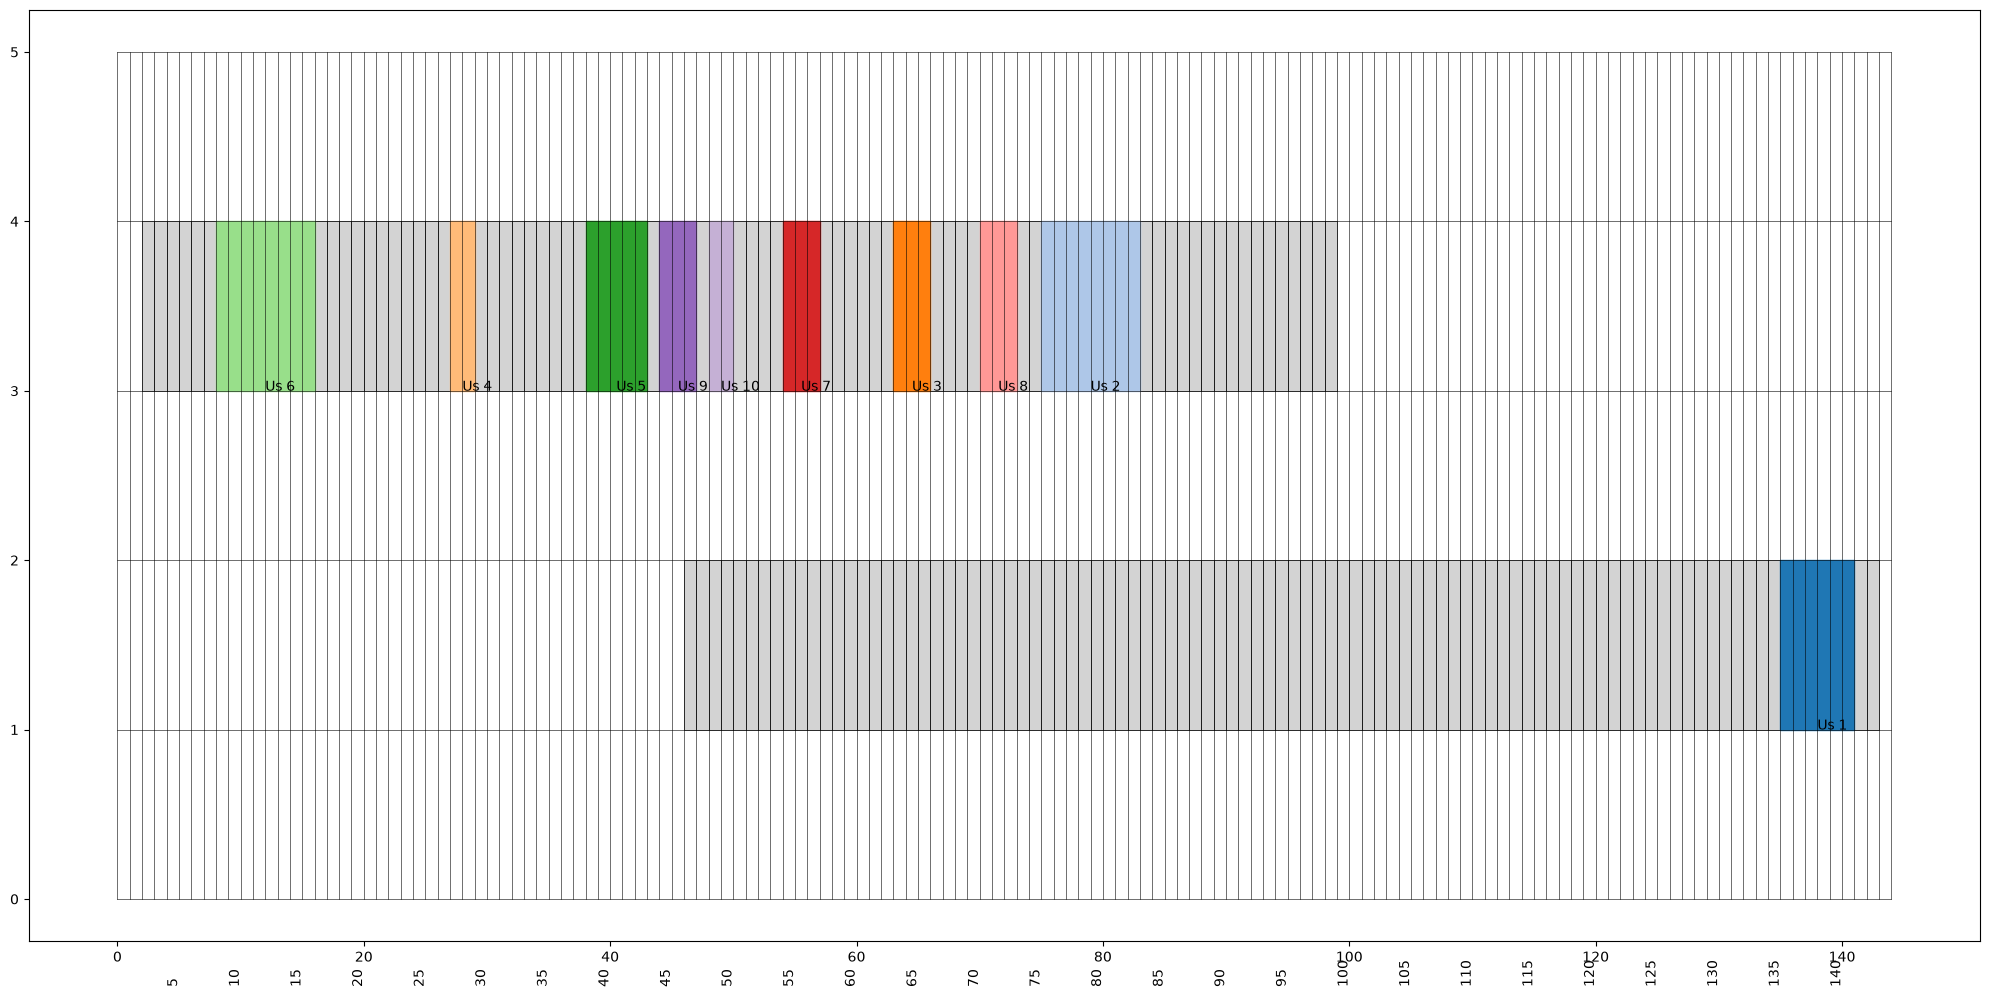

In [98]:
#Visualización del resultado
cmap = plt.get_cmap('tab20')
colors = [cmap(i % cmap.N) for i in range(m+1)] #Para cada paciente o usuario

plt.figure(figsize=(20,10))
ax=plt.gca()
lw=0.4
for j in range(0, n+1):
    plt.plot([0,K],[j,j], '-k', linewidth=lw)
    if(i<=n-1):
        plt.text(-4,i,str(j+1))
for k in range(0, K+1):
    plt.plot([k,k],[0,n], '-k', linewidth=lw)
    if(k<=K-1 and (k+1)%5==0):
        plt.text(k,-0.5,str(k+1), fontsize=10, rotation=90)

for j in range(1,n+1):
    inicio=-1
    for k in range(1,K+1):
        if((j,k) in y.keys()):
            if(y[j,k].varValue>0): #Tiempo de arranque del médico en su turno
                inicio=k
    if(inicio>=0):
        #print(j, list(range(inicio, min(inicio+beta+1, K))))
        for k in range(inicio, min(inicio+beta+1, K)):
            rect = Rectangle(
                (k-1,j-1),          # esquina inferior izquierda (x,y)
                1,               # ancho
                1,             # alto
                facecolor='lightgray', # color de relleno
                edgecolor='black', # borde
                linewidth=lw
            )
            ax.add_patch(rect)
for key,v in x.items():
    if(v.varValue>0):
        i,j,k=key
        for ni in range(0,c[i]):
            rect = Rectangle(
                (k-1+ni, j-1),          # esquina inferior izquierda (x,y)
                1,               # ancho
                1,             # alto
                facecolor=colors[i-1], # color de relleno
                edgecolor=colors[i-1], # borde
                linewidth=1
            )

            ax.add_patch(rect)
        centro=k-1+c[i]/2
        plt.text(centro, j-1, f'Us {i}')
        
plt.tight_layout()

In [99]:
for i in range(1,m+1):
    print(z['S',i], z['S',i].varValue)

Z_Src_1 1.0
Z_Src_2 0.0
Z_Src_3 0.0
Z_Src_4 0.0
Z_Src_5 0.0
Z_Src_6 1.0
Z_Src_7 0.0
Z_Src_8 0.0
Z_Src_9 0.0
Z_Src_10 0.0
